In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
df=pd.read_csv('insurance_data.csv')
df.tail()

,age,bought_insurance
22,40,1
23,45,1
24,50,1
25,54,1
26,23,0


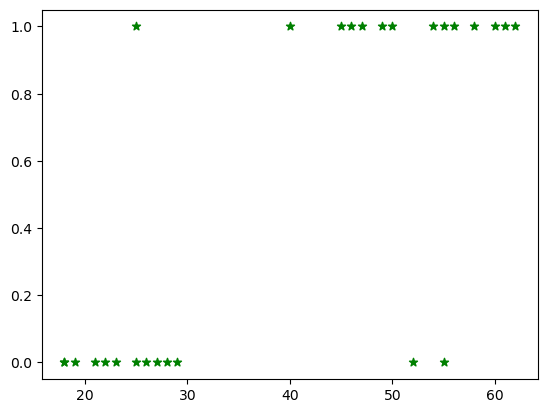

In [4]:
plt.scatter(df.age, df.bought_insurance, marker='*', color='green')

In [7]:
df.shape

(27, 2)

In [13]:
X_train, X_test, y_train, y_test=train_test_split(df[['age']], df['bought_insurance'], test_size=0.2)

In [14]:
X_train.shape

(21, 1)

In [15]:
X_test.shape

(6, 1)

In [17]:
model=LogisticRegression()

In [18]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred=model.predict(X_test)
y_pred[:3]

array([0, 1, 1])

In [21]:
y_pred_prob=model.predict_proba(X_test)
y_pred_prob[:3]

array([[0.97223364, 0.02776636],
       [0.07164074, 0.92835926],
       [0.0494333 , 0.9505667 ]])

In [24]:
#confusion matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[3, 1],
       [1, 1]])

In [27]:
#classification report 
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



In [29]:
#accuracy score
model.score(X_test,y_test)

0.6666666666666666

In [30]:
#Model Coefficients
model.coef_

array([[0.19733954]])

In [31]:
model.intercept_

array([-7.69990106])

In [33]:
#Defining sigmoid function and doing the math 
import math as m
def sigmoid(z):
    return 1/(1 + m.exp(-z))

In [34]:
def prediction_func(age):
    z=0.19*age-7.70
    y=sigmoid(z)
    return y

In [36]:
age=50
prediction_func(age)

0.8581489350995123

In [37]:
#0.85 is more than 0.5 which means person will buy insurance at age of 50

In [38]:
age=20
prediction_func(age)

0.019840305734077503

In [39]:
#0.19 is less than 0.5 which means person will  not buy insurance at age 20